In [36]:
# ── Environment & Dependency Setup ─────────────────────────────────────────
# Detects Google Colab vs local runtime, installs missing packages, and sets
# PROJECT_ROOT.  Edit LOCAL_REPO below if your path differs.

import sys, os, importlib

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Python  : {sys.executable}')

COLAB_REPO = '/content/GML_Edu'
DRIVE_REPO = '/content/drive/MyDrive/GML_Edu'
LOCAL_REPO = 'D:/GitHub/GML_Edu'  # <- edit for your local path

# Colab Drive mount: from google.colab import drive; drive.mount('/content/drive')

if IN_COLAB:
    PROJECT_ROOT = (
        COLAB_REPO if os.path.isdir(COLAB_REPO)
        else DRIVE_REPO if os.path.isdir(DRIVE_REPO)
        else COLAB_REPO
    )
else:
    PROJECT_ROOT = LOCAL_REPO

_rt = 'Google Colab' if IN_COLAB else 'Local'
print(f'Runtime          : {_rt}')
print(f'PROJECT_ROOT     : {PROJECT_ROOT}')
print(f'Repository exists: {os.path.isdir(PROJECT_ROOT)}')

_PACKAGES = [
    ('numpy',      'numpy'),
    ('pandas',     'pandas'),
    ('networkx',   'networkx'),
    ('matplotlib', 'matplotlib'),
    ('plotly',     'plotly'),
    ('nbformat',   'nbformat'),
    ('ipykernel',  'ipykernel'),
]
_missing = [pip for imp, pip in _PACKAGES if importlib.util.find_spec(imp) is None]
if _missing:
    print(f'Installing: {_missing}')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Installation complete.')
else:
    print('All packages present.')

_REPORT = ['numpy', 'pandas', 'networkx', 'matplotlib', 'plotly', 'nbformat']
print('Package versions:')
for _pkg in _REPORT:
    try:
        _m  = importlib.import_module(_pkg)
        _ver = getattr(_m, '__version__', 'unknown')
        print(f'  {_pkg:<20}: {_ver}')
    except ImportError:
        print(f'  {_pkg:<20}: NOT FOUND')

try:
    import networkx, pandas, numpy, matplotlib, plotly, nbformat  # noqa
    print('All library imports   : OK')
except Exception as _e:
    raise ImportError(f'Setup failed: {_e}')

print('Setup complete. Run cells below in order.')

Python  : d:\AI\envs\genai\python.exe
Runtime          : Local
PROJECT_ROOT     : D:/GitHub/GML_Edu
Repository exists: True
All packages present.
Package versions:
  numpy               : 2.4.4
  pandas              : 3.0.3
  networkx            : 3.6.1
  matplotlib          : 3.10.9
  plotly              : 6.8.0
  nbformat            : 5.10.4
All library imports   : OK
Setup complete. Run cells below in order.


> **Status: PREPARED — NOT YET EXECUTED**
>
> Choose `LAYOUT_ID = "BB_01"`, `"BB_02"`, or `"BB_03"` in Section 1.
> Reads graph data directly from Assignment 1 outputs — no file copies needed.
> Each layout writes into its own results and visuals sub-folder.

# MaCAD S.3 — Assignment 2
## A2-01: Graph Metric Computation — Two-Bars Residential Studies

**Assignment objective:** Compute graph-theoretic spatial metrics on the room-and-circulation
graph produced in Assignment 1. All three Two-Bars studies (BB_01, BB_02, BB_03) share the
same schema and run through this notebook unchanged — set `LAYOUT_ID` below.

**Course workflow:** S03 — Spatial Intelligence / Graph Analysis  
**Primary reference notebooks (read-only):**

| Notebook | Metrics covered |
|----------|-----------------|
| `S03-07 Spatial Intelligence Part 1.ipynb` | Closeness, betweenness, density, diameter, shortest paths |
| `S03-08 Spatial Intelligence Part 2.ipynb` | Degree centrality, community detection |
| `S03-09 Spatial Intelligence Part 3.ipynb` | Isovist / visibility — geometry-dependent, not applicable here |

**Key difference from DoubleL workflow:** BB floors are disconnected components
(no stair or lift edges exist). This notebook reports all components explicitly and
computes path-dependent metrics per component rather than silently using the LCC.

### Assignment 2 Requirement Checklist

| # | Requirement | Status |
|---|-------------|--------|
| 1 | Load graph from Assignment 1 dataset | \[ \] Run to confirm |
| 2 | Validate schema and node IDs | \[ \] Run to confirm |
| 3 | Report connected components and sizes | \[ \] Run to confirm |
| 4 | Graph density | \[ \] Run to confirm |
| 5 | Diameter and average path length per component | \[ \] Run to confirm |
| 6 | Degree centrality | \[ \] Run to confirm |
| 7 | Betweenness centrality (per component) | \[ \] Run to confirm |
| 8 | Closeness centrality (Wasserman-Faust) | \[ \] Run to confirm |
| 9 | Clustering coefficient | \[ \] Run to confirm |
| 10 | Community detection (Louvain) | \[ \] Run to confirm |
| 11 | Shortest paths within connected components | \[ \] Run to confirm |
| 12 | Export metrics_table.csv, graph_summary.csv, component_summary.csv, community_summary.csv | \[ \] Run to confirm |
| 13 | Five metric plan visualisations (01–05) with role markers | \[ \] Run to confirm |

---
## 1. Layout Selection and Paths

In [37]:
import os
import warnings
warnings.filterwarnings('ignore')

# ── Layout selector ─────────────────────────────────────────────────────────
# Change only this value to switch between Two-Bars studies.
LAYOUT_ID = 'BB_03'

VALID_LAYOUTS = ('BB_01', 'BB_02', 'BB_03')
if LAYOUT_ID not in VALID_LAYOUTS:
    raise ValueError(f'LAYOUT_ID must be one of {VALID_LAYOUTS}; got {LAYOUT_ID!r}')

LAYOUT_INFO = {
    'BB_01': 'Compact baseline       (2 physical floors)',
    'BB_02': 'Long circulation spine (3 physical floors)',
    'BB_03': 'Wider apartments       (3 physical floors)',
}

# ── Path configuration ──────────────────────────────────────────────────────
# Reads directly from Assignment 1 outputs — no manual CSV copy needed.
A1_ROOT     = os.path.join(PROJECT_ROOT, 'assignments', 'assignment_01_graph_generation')
A1_DATASET  = os.path.join(A1_ROOT, '03_graph_dataset', LAYOUT_ID)

A2_ROOT     = os.path.join(PROJECT_ROOT, 'assignments', 'assignment_02_graph_analysis')
RESULTS_DIR = os.path.join(A2_ROOT, '02_results', LAYOUT_ID)
VISUALS_DIR = os.path.join(A2_ROOT, '03_visuals',  LAYOUT_ID)

NODES_CSV = os.path.join(A1_DATASET, 'nodes.csv')
EDGES_CSV = os.path.join(A1_DATASET, 'edges.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VISUALS_DIR, exist_ok=True)

print(f'Layout   : {LAYOUT_ID} — {LAYOUT_INFO[LAYOUT_ID]}')
print()
print('Path check:')
for _label, _path in [
    ('nodes.csv',  NODES_CSV),
    ('edges.csv',  EDGES_CSV),
    ('results/',   RESULTS_DIR),
    ('visuals/',   VISUALS_DIR),
]:
    _exists = os.path.exists(_path)
    _status = 'OK' if _exists else 'MISSING — run A1_01 first' if _label.endswith('.csv') else 'created'
    print(f'  {_label:12s}: [{_status}]  {_path}')

if not os.path.exists(NODES_CSV) or not os.path.exists(EDGES_CSV):
    raise FileNotFoundError(
        f'Graph dataset for {LAYOUT_ID} not found.\n'
        f'Run A1_01_TwoBars_Geometry_to_Graph.ipynb for {LAYOUT_ID} first.\n'
        f'Expected:\n  {NODES_CSV}\n  {EDGES_CSV}'
    )

Layout   : BB_03 — Wider apartments       (3 physical floors)

Path check:
  nodes.csv   : [OK]  D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\04_graph_dataset\BB_03\nodes.csv
  edges.csv   : [OK]  D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\04_graph_dataset\BB_03\edges.csv
  results/    : [OK]  D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\03_results\BB_03
  visuals/    : [OK]  D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03


---
## 2. Load and Validate Graph Data

In [38]:
import numpy as np
import pandas as pd

nodes = pd.read_csv(NODES_CSV)
edges = pd.read_csv(EDGES_CSV)

print(f'nodes.csv : {len(nodes)} rows')
print(f'edges.csv : {len(edges)} rows')
print()
print(f'Node columns: {list(nodes.columns)}')
print(f'Edge columns: {list(edges.columns)}')
print()
print('Nodes by node_role:')
print(nodes['node_role'].value_counts().to_string())
print()

PF_COL = 'physical_floor' if 'physical_floor' in nodes.columns else 'floor_id'
print(f'Nodes by {PF_COL}:')
print(nodes[PF_COL].value_counts().sort_index().to_string())
print()
print('Nodes by space_type:')
print(nodes['space_type'].value_counts().to_string())

nodes.csv : 141 rows
edges.csv : 303 rows

Node columns: ['layout_id', 'node_id', 'node_name', 'node_role', 'space_type', 'zone_type', 'apartment_id', 'floor_id', 'physical_floor', 'area', 'volume', 'X', 'Y', 'Z']
Edge columns: ['layout_id', 'src_id', 'dst_id', 'edge_type', 'contact_axis', 'gap_m', 'shared_span_m', 'physical_floor']

Nodes by node_role:
node_role
room        120
corridor     18
core          3

Nodes by physical_floor:
physical_floor
0    46
1    47
2    48

Nodes by space_type:
space_type
Bath        24
Hall        24
Kitchen     24
Living      24
Corridor    18
Bedroom1     8
Bedroom      8
Bedroom2     8
Core         3


In [39]:
# Schema and ID validation
REQUIRED_NODE_COLS = ['node_id', 'node_role', 'space_type', 'floor_id', 'area', 'X', 'Y', 'Z']
REQUIRED_EDGE_COLS = ['src_id', 'dst_id']

_missing_n = [c for c in REQUIRED_NODE_COLS if c not in nodes.columns]
_missing_e = [c for c in REQUIRED_EDGE_COLS if c not in edges.columns]
if _missing_n:
    raise ValueError(f'nodes.csv missing columns: {_missing_n}')
if _missing_e:
    raise ValueError(f'edges.csv missing columns: {_missing_e}')

_dup_ids = nodes[nodes['node_id'].duplicated()]['node_id'].tolist()
if _dup_ids:
    print(f'WARNING: {len(_dup_ids)} duplicate node_id values: {_dup_ids[:5]}')
else:
    print('Node IDs      : no duplicates')

_all_ids = set(nodes['node_id'].astype(int))
_bad_src = set(edges['src_id'].astype(int)) - _all_ids
_bad_dst = set(edges['dst_id'].astype(int)) - _all_ids
if _bad_src or _bad_dst:
    print(f'WARNING: edge references unknown nodes — src={len(_bad_src)} dst={len(_bad_dst)}')
else:
    print('Edge references: all node IDs valid')

print(f'Schema validation passed for {LAYOUT_ID}.')

Node IDs      : no duplicates
Edge references: all node IDs valid
Schema validation passed for BB_03.


---
## 3. NetworkX Graph and Per-Component Analysis

BB floors are disconnected components: stair and lift edges are not present in this
dataset (no vertical geometry was exported). Path-dependent metrics (betweenness,
closeness, diameter, average path length) are computed within each component.

**Do not silently drop to the largest connected component (LCC).**  
All components are reported and used.

In [40]:
import networkx as nx

G = nx.Graph()
for _, row in nodes.iterrows():
    G.add_node(int(row['node_id']), **row.to_dict())
for _, row in edges.iterrows():
    _src, _dst = int(row['src_id']), int(row['dst_id'])
    if _src in G and _dst in G and _src != _dst:
        G.add_edge(_src, _dst)

print(f'NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Density              : {nx.density(G):.6f}')
print(f'Connected components : {nx.number_connected_components(G)}')
print(f'Isolated nodes       : {len(list(nx.isolates(G)))}')
print()

# Per-component analysis
_comps_raw = list(nx.connected_components(G))
COMPS = sorted(_comps_raw, key=len, reverse=True)
NODE_TO_COMP = {}
for _ci, _cn in enumerate(COMPS):
    for _v in _cn:
        NODE_TO_COMP[_v] = _ci

comp_records = []
for _ci, _comp_nodes in enumerate(COMPS):
    _sub = G.subgraph(_comp_nodes).copy()
    _n   = len(_comp_nodes)
    _floors = sorted({
        G.nodes[v].get(PF_COL)
        for v in _comp_nodes
        if G.nodes[v].get(PF_COL) is not None
    })
    _roles = {r: sum(1 for v in _comp_nodes if G.nodes[v].get('node_role') == r)
              for r in ('room', 'corridor', 'core')}
    _diam     = nx.diameter(_sub) if _n > 1 else 0
    _avg_path = nx.average_shortest_path_length(_sub) if _n > 1 else 0.0

    print(f'Component {_ci}:')
    print(f'  nodes        : {_n}')
    print(f'  {PF_COL}s  : {_floors}')
    print(f'  roles        : rooms={_roles["room"]}  corridors={_roles["corridor"]}  cores={_roles["core"]}')
    print(f'  diameter     : {_diam}')
    print(f'  avg path len : {_avg_path:.3f}')
    print()

    comp_records.append({
        'component_id'    : _ci,
        'n_nodes'         : _n,
        'n_edges'         : _sub.number_of_edges(),
        'physical_floors' : str(_floors),
        'rooms'           : _roles['room'],
        'corridors'       : _roles['corridor'],
        'cores'           : _roles['core'],
        'diameter'        : _diam,
        'avg_path_len'    : round(_avg_path, 4),
    })

print(f'Component membership assigned to {len(NODE_TO_COMP)} nodes.')

NetworkX graph: 141 nodes, 303 edges
Density              : 0.030699
Connected components : 3
Isolated nodes       : 0

Component 0:
  nodes        : 48
  physical_floors  : [2]
  roles        : rooms=41  corridors=6  cores=1
  diameter     : 7
  avg path len : 3.758

Component 1:
  nodes        : 47
  physical_floors  : [1]
  roles        : rooms=40  corridors=6  cores=1
  diameter     : 7
  avg path len : 3.860

Component 2:
  nodes        : 46
  physical_floors  : [0]
  roles        : rooms=39  corridors=6  cores=1
  diameter     : 7
  avg path len : 3.676

Component membership assigned to 141 nodes.


---
## 4. Graph-Level Statistics

Density measures how many edges exist relative to the maximum possible.
A double-loaded corridor building should be sparse (tree-like spine with small cliques).

**Architectural prompt:** High density suggests spatial promiscuity — many shared walls
between many room pairs. Low density (< 0.05) is typical for residential buildings
where rooms connect through a corridor hierarchy rather than directly.

In [41]:
_density = nx.density(G)

print('=' * 52)
print('GRAPH-LEVEL STATISTICS')
print('=' * 52)
print(f'  Layout              : {LAYOUT_ID}')
print(f'  Nodes               : {G.number_of_nodes()}')
print(f'  Edges               : {G.number_of_edges()}')
print(f'  Density             : {_density:.6f}')
print(f'  Connected components: {len(COMPS)}')
for _rec in comp_records:
    print(f'    Comp {_rec["component_id"]}: {_rec["n_nodes"]} nodes  '
          f'diam={_rec["diameter"]}  avg_path={_rec["avg_path_len"]}  '
          f'floors={_rec["physical_floors"]}')
print('=' * 52)

GRAPH-LEVEL STATISTICS
  Layout              : BB_03
  Nodes               : 141
  Edges               : 303
  Density             : 0.030699
  Connected components: 3
    Comp 0: 48 nodes  diam=7  avg_path=3.758  floors=[2]
    Comp 1: 47 nodes  diam=7  avg_path=3.8603  floors=[1]
    Comp 2: 46 nodes  diam=7  avg_path=3.6763  floors=[0]


---
## 5. Degree Centrality

**Course API:** `Graph.DegreeCentrality` (S03-08). Computed here with NetworkX.

**Architectural prompt:** Degree centrality counts the fraction of other nodes directly
adjacent. In a double-loaded corridor building, corridor nodes should dominate because
each corridor face-touches multiple apartment halls simultaneously.

In [42]:
DC = nx.degree_centrality(G)
RAW_DEG = dict(G.degree())

_vals = list(DC.values())
print(f'Degree centrality: min={min(_vals):.4f}  max={max(_vals):.4f}  mean={sum(_vals)/len(_vals):.4f}')
print()
print(f'{"node":>5}  {"deg":>4}  {"dc":>7}  {"role":10}  {"type":12}  {"comp":>5}  {PF_COL}')
print('-' * 66)
for _nid, _val in sorted(DC.items(), key=lambda x: -x[1])[:12]:
    _a = G.nodes[_nid]
    print(f'{_nid:>5}  {RAW_DEG[_nid]:>4}  {_val:.5f}  '
          f'{str(_a.get("node_role","?")):<10}  '
          f'{str(_a.get("space_type","?")):<12}  '
          f'{NODE_TO_COMP.get(_nid,"?"):>5}  '
          f'{_a.get(PF_COL,"?")}')
print()
print('Mean degree centrality by node_role:')
for _role in ('room', 'corridor', 'core'):
    _role_vals = [DC[n] for n in G.nodes() if G.nodes[n].get('node_role') == _role]
    if _role_vals:
        print(f'  {_role:10s}: mean={sum(_role_vals)/len(_role_vals):.4f}  '
              f'max={max(_role_vals):.4f}  n={len(_role_vals)}')

Degree centrality: min=0.0143  max=0.0571  mean=0.0307

 node   deg       dc  role        type           comp  physical_floor
------------------------------------------------------------------
  126     8  0.05714  corridor    Corridor          0  2
  129     8  0.05714  corridor    Corridor          2  0
  130     8  0.05714  corridor    Corridor          2  0
  131     8  0.05714  corridor    Corridor          2  0
  133     8  0.05714  corridor    Corridor          1  1
  134     8  0.05714  corridor    Corridor          1  1
  136     8  0.05714  corridor    Corridor          0  2
  137     8  0.05714  corridor    Corridor          0  2
  120     7  0.05000  corridor    Corridor          2  0
  121     7  0.05000  corridor    Corridor          2  0
  122     7  0.05000  corridor    Corridor          2  0
  124     7  0.05000  corridor    Corridor          1  1

Mean degree centrality by node_role:
  room      : mean=0.0271  max=0.0429  n=120
  corridor  : mean=0.0524  max=0.0571  n

---
## 6. Betweenness Centrality

**Course API:** `Graph.BetweennessCentrality` (S03-07). Computed here per-component
with NetworkX to avoid cross-component normalization distortion.

**Architectural prompt:** High betweenness = circulation bottleneck. Removing that node
would most disrupt room-to-room access. Corridors near the building midpoint of each
floor should rank highest.

In [43]:
# Betweenness computed per-component; merged into a single dict keyed by node_id.
# Per-component normalization: each component's score range is [0, 1] independently.
print('Computing betweenness centrality per component...')

BC = {}
for _ci, _comp_nodes in enumerate(COMPS):
    _sub = G.subgraph(_comp_nodes).copy()
    _bc_sub = nx.betweenness_centrality(_sub, normalized=True)
    BC.update(_bc_sub)
    _bvals = list(_bc_sub.values())
    print(f'  Component {_ci}: {len(_comp_nodes)} nodes  '
          f'bc range [{min(_bvals):.4f}, {max(_bvals):.4f}]')

print()
print(f'{"node":>5}  {"bc":>8}  {"role":10}  {"type":12}  {"comp":>5}  {PF_COL}')
print('-' * 68)
for _nid, _val in sorted(BC.items(), key=lambda x: -x[1])[:12]:
    _a = G.nodes[_nid]
    print(f'{_nid:>5}  {_val:.6f}  '
          f'{str(_a.get("node_role","?")):<10}  '
          f'{str(_a.get("space_type","?")):<12}  '
          f'{NODE_TO_COMP.get(_nid,"?"):>5}  '
          f'{_a.get(PF_COL,"?")}')
print()
print('Mean betweenness by node_role:')
for _role in ('room', 'corridor', 'core'):
    _rv = [BC[n] for n in G.nodes() if G.nodes[n].get('node_role') == _role]
    if _rv:
        print(f'  {_role:10s}: mean={sum(_rv)/len(_rv):.5f}  max={max(_rv):.5f}  n={len(_rv)}')

Computing betweenness centrality per component...
  Component 0: 48 nodes  bc range [0.0000, 0.5581]
  Component 1: 47 nodes  bc range [0.0000, 0.5391]
  Component 2: 46 nodes  bc range [0.0000, 0.5433]

 node        bc  role        type           comp  physical_floor
--------------------------------------------------------------------
  140  0.558107  core        Core              0  2
  138  0.543287  core        Core              2  0
  139  0.539062  core        Core              1  1
  120  0.390630  corridor    Corridor          2  0
  123  0.376564  corridor    Corridor          1  1
  126  0.350169  corridor    Corridor          0  2
  136  0.322678  corridor    Corridor          0  2
  137  0.318555  corridor    Corridor          0  2
  130  0.293379  corridor    Corridor          2  0
  134  0.286855  corridor    Corridor          1  1
  131  0.273700  corridor    Corridor          2  0
  133  0.266603  corridor    Corridor          1  1

Mean betweenness by node_role:
  room

---
## 7. Closeness Centrality

**Course API:** `Graph.ClosenessCentrality` (S03-07). NetworkX applies the
Wasserman-Faust normalization here, which adjusts for each node's reachable
fraction — this makes closeness meaningful for disconnected graphs.

**Architectural prompt:** High closeness = spatially central — shortest average
walking distance to all reachable rooms. Corridors near the floor midpoint should
score highest within each component.

In [44]:
# nx.closeness_centrality uses Wasserman-Faust normalization for disconnected graphs.
print('Computing closeness centrality (Wasserman-Faust normalization)...')

CC = nx.closeness_centrality(G)

_vals = list(CC.values())
print(f'Closeness: min={min(_vals):.4f}  max={max(_vals):.4f}  mean={sum(_vals)/len(_vals):.4f}')
print()
print(f'{"node":>5}  {"cc":>7}  {"role":10}  {"type":12}  {"comp":>5}  {PF_COL}')
print('-' * 62)
for _nid, _val in sorted(CC.items(), key=lambda x: -x[1])[:12]:
    _a = G.nodes[_nid]
    print(f'{_nid:>5}  {_val:.5f}  '
          f'{str(_a.get("node_role","?")):<10}  '
          f'{str(_a.get("space_type","?")):<12}  '
          f'{NODE_TO_COMP.get(_nid,"?"):>5}  '
          f'{_a.get(PF_COL,"?")}')
print()
print('Mean closeness by node_role:')
for _role in ('room', 'corridor', 'core'):
    _rv = [CC[n] for n in G.nodes() if G.nodes[n].get('node_role') == _role]
    if _rv:
        print(f'  {_role:10s}: mean={sum(_rv)/len(_rv):.4f}  max={max(_rv):.4f}  n={len(_rv)}')

Computing closeness centrality (Wasserman-Faust normalization)...
Closeness: min=0.0646  max=0.1434  mean=0.0900

 node       cc  role        type           comp  physical_floor
--------------------------------------------------------------
  140  0.14344  core        Core              0  2
  138  0.13908  core        Core              2  0
  139  0.13375  core        Core              1  1
  126  0.13149  corridor    Corridor          0  2
  123  0.12809  corridor    Corridor          1  1
  120  0.12800  corridor    Corridor          2  0
  135  0.12137  corridor    Corridor          0  2
  129  0.11954  corridor    Corridor          2  0
   29  0.11864  room        Living            0  2
  136  0.11864  corridor    Corridor          0  2
  137  0.11864  corridor    Corridor          0  2
   19  0.11808  room        Living            1  1

Mean closeness by node_role:
  room      : mean=0.0852  max=0.1186  n=120
  corridor  : mean=0.1142  max=0.1315  n=18
  core      : mean=0.1388  m

---
## 8. Clustering Coefficient

**NetworkX:** `nx.clustering(G)` — valid on disconnected graphs.

**Architectural prompt:** What fraction of a node's neighbours are also adjacent to each
other? Low clustering in corridors (hub-spoke structure) vs higher clustering in rooms
that form tight apartment cliques.

In [45]:
CLUST = nx.clustering(G)
_global = nx.average_clustering(G)

_vals = list(CLUST.values())
print(f'Clustering coefficient:')
print(f'  Global average : {_global:.4f}')
print(f'  Max            : {max(_vals):.4f}')
print(f'  Min            : {min(_vals):.4f}')
print(f'  Zero-cluster   : {sum(1 for v in _vals if v == 0)} nodes')
print()
print('By node_role:')
for _role in ('room', 'corridor', 'core'):
    _rv = [CLUST[n] for n in G.nodes() if G.nodes[n].get('node_role') == _role]
    if _rv:
        print(f'  {_role:10s}: mean={sum(_rv)/len(_rv):.4f}  max={max(_rv):.4f}  n={len(_rv)}')
print()
print('By space_type (top 6):')
_by_type = {}
for _n in G.nodes():
    _st = G.nodes[_n].get('space_type', 'unknown')
    _by_type.setdefault(_st, []).append(CLUST[_n])
for _st, _vals_t in sorted(_by_type.items(), key=lambda x: -sum(x[1])/len(x[1]))[:6]:
    _mean = sum(_vals_t) / len(_vals_t)
    print(f'  {_st:12s}: mean={_mean:.4f}  n={len(_vals_t)}')

Clustering coefficient:
  Global average : 0.5389
  Max            : 1.0000
  Min            : 0.2381
  Zero-cluster   : 0 nodes

By node_role:
  room      : mean=0.5856  max=1.0000  n=120
  corridor  : mean=0.2751  max=0.3333  n=18
  core      : mean=0.2571  max=0.2667  n=3

By space_type (top 6):
  Bedroom     : mean=0.7292  n=8
  Living      : mean=0.6458  n=24
  Kitchen     : mean=0.6389  n=24
  Bath        : mean=0.6111  n=24
  Bedroom2    : mean=0.5833  n=8
  Bedroom1    : mean=0.5625  n=8


---
## 9. Community Detection

**Course API:** `Graph.CommunityPartition` (S03-08) uses Louvain.
Implemented here with NetworkX (`louvain_communities`) with a greedy-modularity fallback.

**Architectural prompt:** If communities align with apartments, the graph correctly
encodes the design's ownership boundaries. Misalignment reveals where spatial
topology diverges from the architect's grouping intent.

In [46]:
import networkx.algorithms.community as nx_comm

try:
    ALL_COMMUNITIES = nx_comm.louvain_communities(G, seed=42)
    COMM_METHOD = 'Louvain'
except AttributeError:
    ALL_COMMUNITIES = list(nx_comm.greedy_modularity_communities(G))
    COMM_METHOD = 'greedy modularity'

print(f'Community detection : {COMM_METHOD}')
print(f'Communities found   : {len(ALL_COMMUNITIES)}')
print()

NODE_TO_COMM = {}
for _ci, _cn in enumerate(sorted(ALL_COMMUNITIES, key=len, reverse=True)):
    for _v in _cn:
        NODE_TO_COMM[_v] = _ci

comm_records = []
for _ci, _cn in enumerate(sorted(ALL_COMMUNITIES, key=len, reverse=True)):
    _roles = {r: sum(1 for n in _cn if G.nodes[n].get('node_role') == r)
              for r in ('room', 'corridor', 'core')}
    _floors = sorted({G.nodes[n].get(PF_COL) for n in _cn
                      if G.nodes[n].get(PF_COL) is not None})
    comm_records.append({
        'community_id' : _ci,
        'n_nodes'      : len(_cn),
        'rooms'        : _roles['room'],
        'corridors'    : _roles['corridor'],
        'cores'        : _roles['core'],
        'floors'       : str(_floors),
    })
    print(f'  Comm {_ci:2d}: {len(_cn):3d} nodes  '
          f'rooms={_roles["room"]}  corridors={_roles["corridor"]}  '
          f'cores={_roles["core"]}  floors={_floors}')

print()
_n_apts = nodes['apartment_id'].nunique() if 'apartment_id' in nodes.columns else 'unknown'
print(f'Expected apartments  : {_n_apts} unique apartment_id values')

Community detection : Louvain
Communities found   : 11

  Comm  0:  24 nodes  rooms=20  corridors=3  cores=1  floors=[2]
  Comm  1:  14 nodes  rooms=11  corridors=2  cores=1  floors=[0]
  Comm  2:  13 nodes  rooms=11  corridors=2  cores=0  floors=[1]
  Comm  3:  13 nodes  rooms=10  corridors=2  cores=1  floors=[1]
  Comm  4:  13 nodes  rooms=11  corridors=2  cores=0  floors=[2]
  Comm  5:  13 nodes  rooms=11  corridors=2  cores=0  floors=[0]
  Comm  6:  11 nodes  rooms=10  corridors=1  cores=0  floors=[1]
  Comm  7:  11 nodes  rooms=10  corridors=1  cores=0  floors=[2]
  Comm  8:  10 nodes  rooms=9  corridors=1  cores=0  floors=[1]
  Comm  9:  10 nodes  rooms=9  corridors=1  cores=0  floors=[0]
  Comm 10:   9 nodes  rooms=8  corridors=1  cores=0  floors=[0]

Expected apartments  : 23 unique apartment_id values


---
## 10. Shortest Paths

**Course API:** `Graph.ShortestPath` with `CompiledRoutingGraph` (S03-07).
Computed here with NetworkX `shortest_path` within each connected component.

Cross-component paths (between floors) are not computed because no inter-floor
edges exist in this dataset.

In [47]:
path_results = []

for _ci, _comp_nodes in enumerate(COMPS):
    _sub   = G.subgraph(_comp_nodes).copy()
    _nodes = sorted(_comp_nodes)

    _rooms = [n for n in _nodes if G.nodes[n].get('node_role') == 'room']
    _corrs = [n for n in _nodes if G.nodes[n].get('node_role') == 'corridor']
    _cores = [n for n in _nodes if G.nodes[n].get('node_role') == 'core']

    _floors = sorted({G.nodes[n].get(PF_COL) for n in _nodes
                      if G.nodes[n].get(PF_COL) is not None})
    print(f'Component {_ci} (floors={_floors}, {len(_nodes)} nodes):')

    _pairs = []
    if len(_rooms) >= 2:
        _pairs.append((_rooms[0], _rooms[-1], 'room -> room'))
    if _rooms and _corrs:
        _pairs.append((_rooms[0], _corrs[0], 'room -> corridor'))
    if _corrs and _cores:
        _pairs.append((_corrs[0], _cores[0], 'corridor -> core'))

    for _src, _dst, _label in _pairs:
        try:
            _path  = nx.shortest_path(_sub, _src, _dst)
            _hops  = len(_path) - 1
            _types = [G.nodes[n].get('space_type', '?') for n in _path]
            print(f'  {_label:22s}: {_hops} hops  {" -> ".join(_types)}')
            path_results.append({'component': _ci, 'label': _label,
                                  'src': _src, 'dst': _dst, 'hops': _hops})
        except nx.NetworkXNoPath:
            print(f'  {_label:22s}: no path — check graph integrity')
    print()

print(f'Paths computed: {len(path_results)}')

Component 0 (floors=[2], 48 nodes):
  room -> room          : 6 hops  Bath -> Corridor -> Corridor -> Core -> Corridor -> Hall -> Living
  room -> corridor      : 2 hops  Bath -> Corridor -> Corridor
  corridor -> core      : 1 hops  Corridor -> Core

Component 1 (floors=[1], 47 nodes):
  room -> room          : 6 hops  Bath -> Corridor -> Living -> Core -> Corridor -> Hall -> Kitchen
  room -> corridor      : 2 hops  Bath -> Corridor -> Corridor
  corridor -> core      : 1 hops  Corridor -> Core

Component 2 (floors=[0], 46 nodes):
  room -> room          : 6 hops  Bath -> Corridor -> Corridor -> Core -> Corridor -> Hall -> Living
  room -> corridor      : 2 hops  Bath -> Corridor -> Corridor
  corridor -> core      : 1 hops  Corridor -> Core

Paths computed: 9


---
## 11. Export Metric Tables

Outputs:
- `metrics_table.csv` — per-node: degree, betweenness, closeness, clustering, community, component
- `graph_summary.csv` — graph-level: density, component count, community count
- `component_summary.csv` — per-component: nodes, diameter, avg path length
- `community_summary.csv` — per-community: size, role counts

In [48]:
_metric_rows = []
for _, _row in nodes.iterrows():
    _nid = int(_row['node_id'])
    _entry = {
        'layout_id'   : LAYOUT_ID,
        'node_id'     : _nid,
        'node_role'   : _row.get('node_role', ''),
        'space_type'  : _row.get('space_type', ''),
        'floor_id'    : _row.get('floor_id'),
        PF_COL        : _row.get(PF_COL),
        'component_id': NODE_TO_COMP.get(_nid, -1),
        'community_id': NODE_TO_COMM.get(_nid, -1),
        'degree'      : G.degree(_nid) if _nid in G else 0,
        'degree_cent' : round(DC.get(_nid,    0.0), 6),
        'betweenness' : round(BC.get(_nid,    0.0), 6),
        'closeness'   : round(CC.get(_nid,    0.0), 6),
        'clustering'  : round(CLUST.get(_nid, 0.0), 6),
    }
    _metric_rows.append(_entry)

metrics_df = pd.DataFrame(_metric_rows)
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'metrics_table.csv'), index=False)
print(f'metrics_table.csv     : {len(metrics_df)} rows')

graph_sum = pd.DataFrame([{
    'layout_id'      : LAYOUT_ID,
    'n_nodes'        : G.number_of_nodes(),
    'n_edges'        : G.number_of_edges(),
    'density'        : round(nx.density(G), 6),
    'n_components'   : len(COMPS),
    'avg_clustering' : round(nx.average_clustering(G), 6),
    'n_communities'  : len(ALL_COMMUNITIES),
}])
graph_sum.to_csv(os.path.join(RESULTS_DIR, 'graph_summary.csv'), index=False)
print(f'graph_summary.csv     : 1 row')

comp_df = pd.DataFrame(comp_records)
comp_df.insert(0, 'layout_id', LAYOUT_ID)
comp_df.to_csv(os.path.join(RESULTS_DIR, 'component_summary.csv'), index=False)
print(f'component_summary.csv : {len(comp_df)} rows')

comm_df = pd.DataFrame(comm_records)
comm_df.insert(0, 'layout_id', LAYOUT_ID)
comm_df.to_csv(os.path.join(RESULTS_DIR, 'community_summary.csv'), index=False)
print(f'community_summary.csv : {len(comm_df)} rows')

print()
print(metrics_df.describe().round(4))

metrics_table.csv     : 141 rows
graph_summary.csv     : 1 row
component_summary.csv : 3 rows
community_summary.csv : 11 rows

        node_id  floor_id  physical_floor  component_id  community_id  \
count  141.0000  141.0000        141.0000      141.0000      141.0000   
mean    70.0000    2.3050          1.0142        0.9858        4.2482   
std     40.8473    1.7027          0.8193        0.8193        3.2252   
min      0.0000    0.0000          0.0000        0.0000        0.0000   
25%     35.0000    1.0000          0.0000        0.0000        1.0000   
50%     70.0000    2.0000          1.0000        1.0000        4.0000   
75%    105.0000    4.0000          2.0000        2.0000        7.0000   
max    140.0000    5.0000          2.0000        2.0000       10.0000   

         degree  degree_cent  betweenness  closeness  clustering  
count  141.0000     141.0000     141.0000   141.0000    141.0000  
mean     4.2979       0.0307       0.0614     0.0900      0.5389  
std      1.566

---
## 12. Metric Visualisations

Each figure shows the graph in XY plan coordinates (metres).  
Node colour encodes metric value (YlOrRd: yellow = low, red = high).  
Node shape encodes spatial role:
- **○ circle** — room  
- **◆ diamond** — corridor  
- **★ star** — core

In [49]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'

# XY plan positions (metres from node centroids)
POS_XY = {int(r['node_id']): (float(r['X']), float(r['Y'])) for _, r in nodes.iterrows()}

# Role display settings
ROLE_MARKER = {'room': 'o', 'corridor': 'D', 'core': '*'}
ROLE_SIZE   = {'room': 45,  'corridor': 120, 'core': 160}
ROLE_EW     = {'room': 0.0, 'corridor': 0.6, 'core': 1.0}
ROLE_EC     = {'room': 'none', 'corridor': '#333333', 'core': '#111111'}

METRIC_CMAP = plt.cm.YlOrRd


def draw_metric_plan(ax, metric_dict, title, cmap=None):
    """Scatter plot of graph in XY plan, coloured by metric_dict values."""
    _cmap = cmap or METRIC_CMAP
    _vals = np.array([metric_dict.get(n, 0.0) for n in G.nodes()], dtype=float)
    _norm = Normalize(vmin=_vals.min(), vmax=max(_vals.max(), 1e-9))

    # Draw edges
    for _u, _v in G.edges():
        _x0, _y0 = POS_XY.get(_u, (0, 0))
        _x1, _y1 = POS_XY.get(_v, (0, 0))
        ax.plot([_x0, _x1], [_y0, _y1], color='#CCCCCC', lw=0.4, zorder=1)

    # Draw nodes by role so markers are distinct per spatial type
    for _role in ('room', 'corridor', 'core'):
        _rn = [n for n in G.nodes() if G.nodes[n].get('node_role') == _role]
        if not _rn:
            continue
        _xs = [POS_XY[n][0] for n in _rn]
        _ys = [POS_XY[n][1] for n in _rn]
        _cs = [_cmap(_norm(metric_dict.get(n, 0.0))) for n in _rn]
        ax.scatter(_xs, _ys, c=_cs, s=ROLE_SIZE[_role],
                   marker=ROLE_MARKER[_role],
                   edgecolors=ROLE_EC[_role],
                   linewidths=ROLE_EW[_role], zorder=3)

    _sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    _sm.set_array([])
    plt.colorbar(_sm, ax=ax, shrink=0.4, label=title)
    ax.set_title(f'{LAYOUT_ID} — {title}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=8)
    ax.set_ylabel('Y (m)', fontsize=8)
    ax.set_aspect('equal')


ROLE_LEGEND = [
    mpatches.Patch(facecolor='#AAAAAA', edgecolor='none',    label='room  (circle)'),
    mpatches.Patch(facecolor='#AAAAAA', edgecolor='#333333', label='corridor (diamond)'),
    mpatches.Patch(facecolor='#AAAAAA', edgecolor='#111111', label='core  (star)'),
]

print('Visualisation helpers ready.')

Visualisation helpers ready.


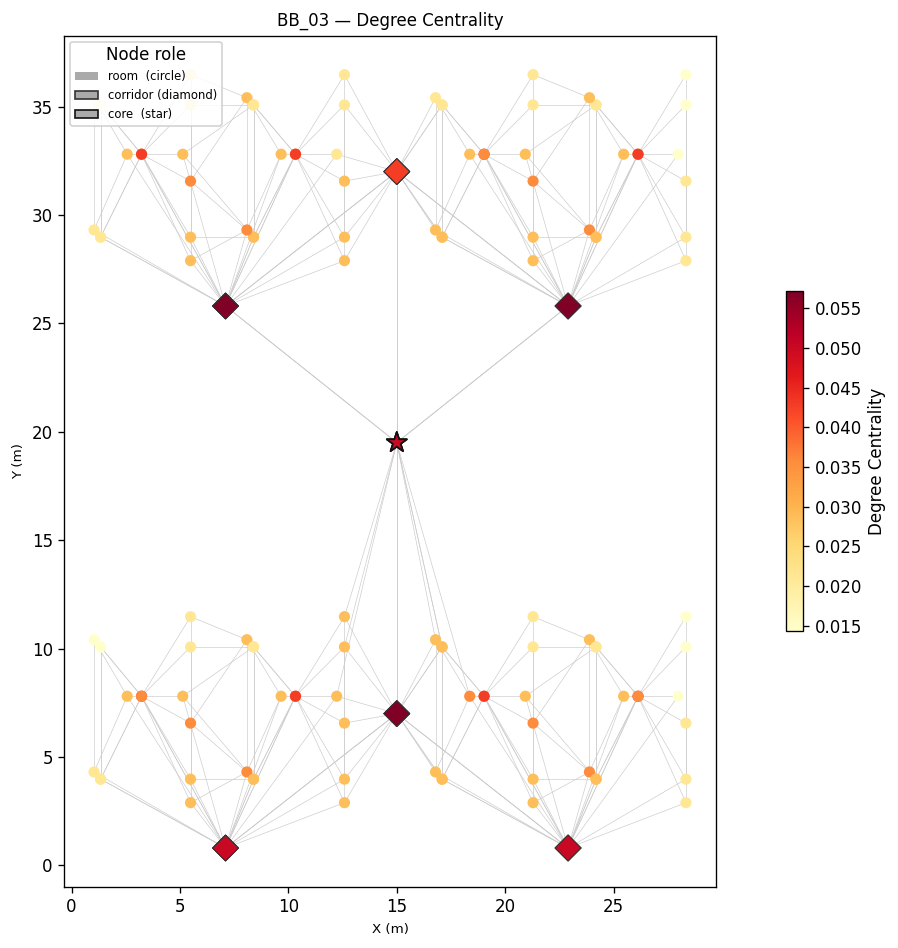

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03\01_degree_centrality.png


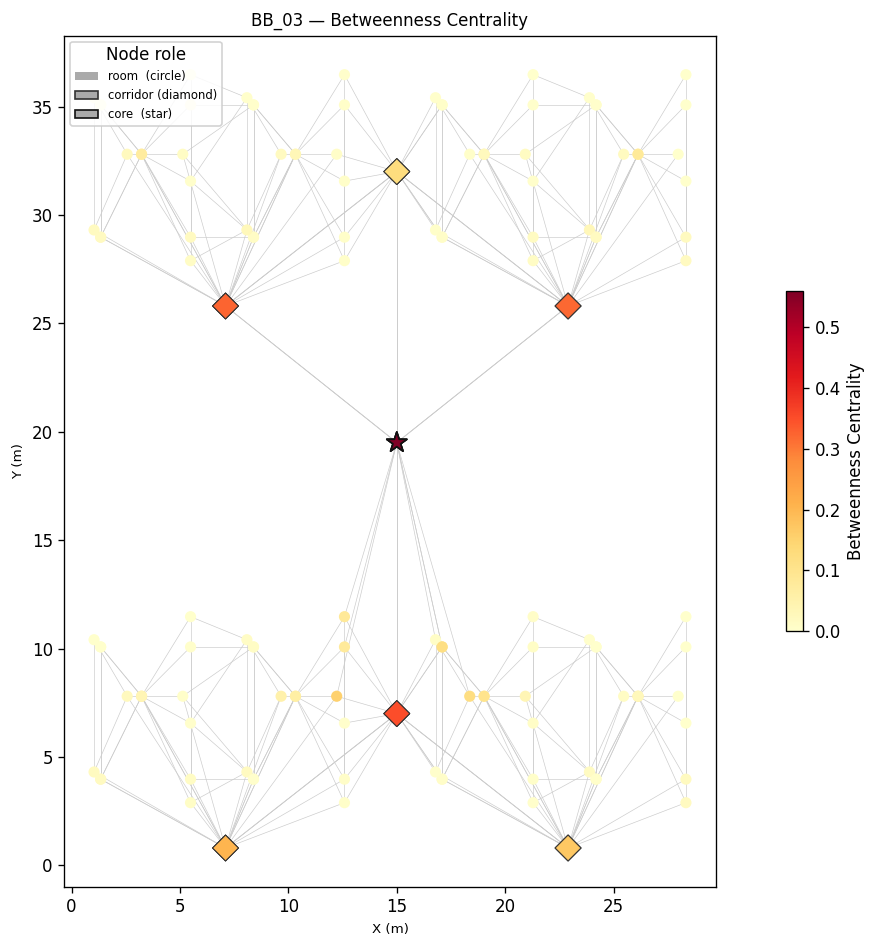

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03\02_betweenness_centrality.png


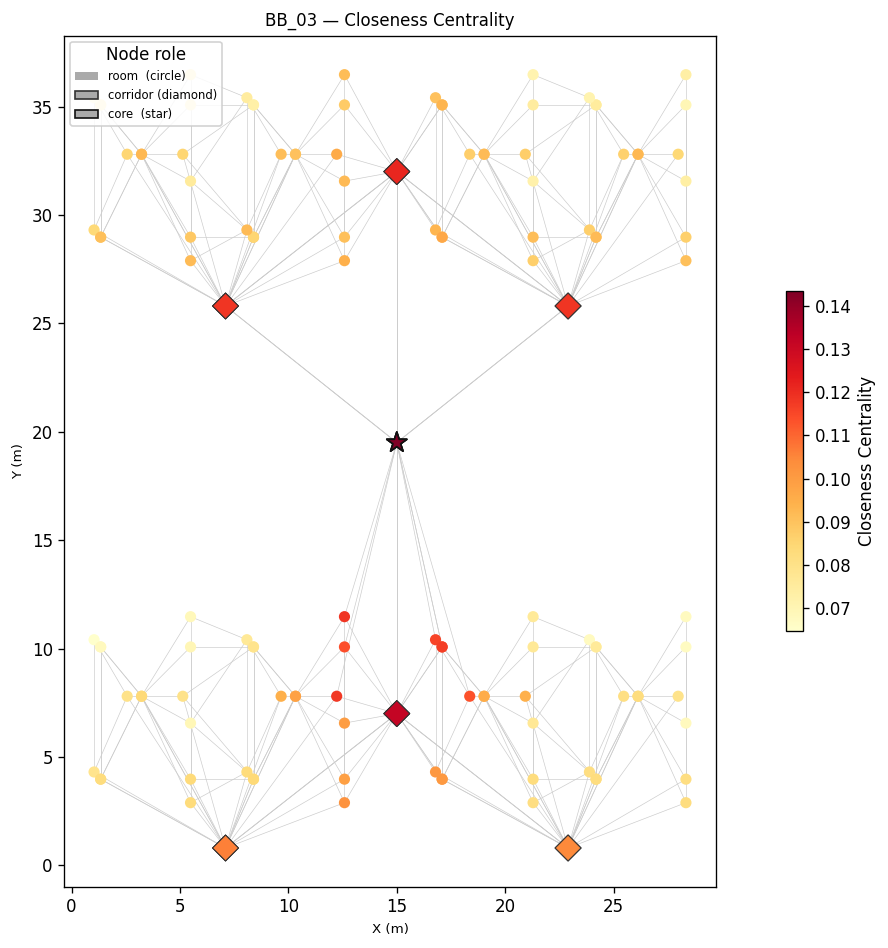

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03\03_closeness_centrality.png


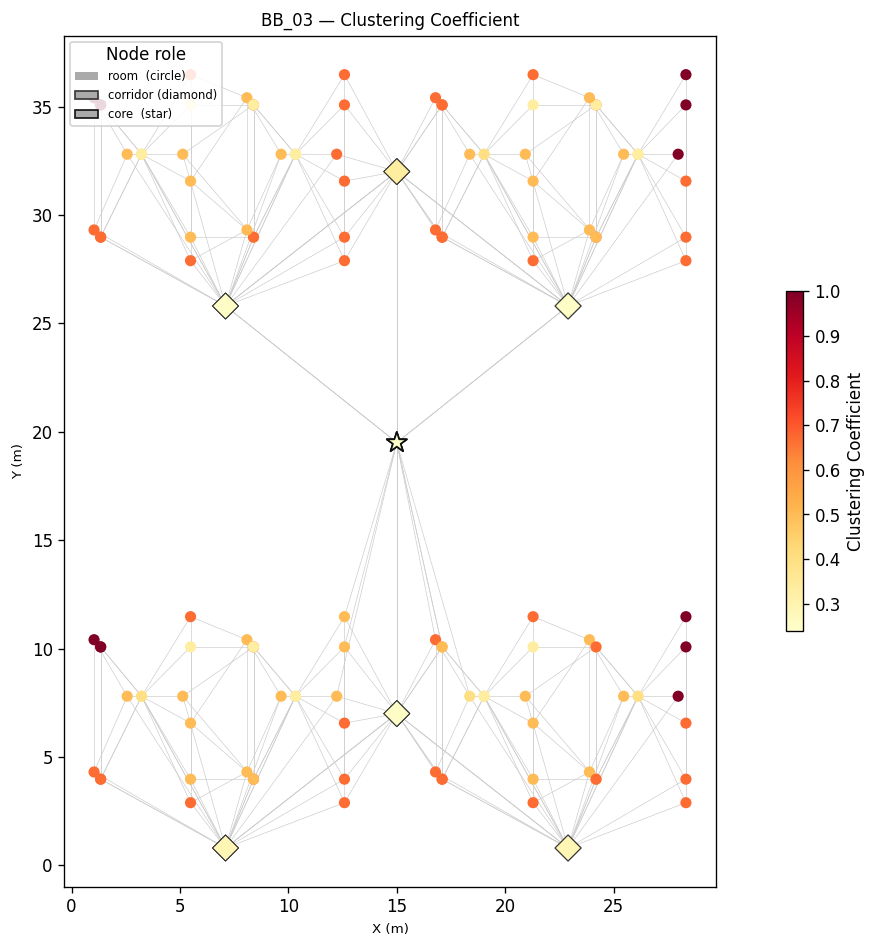

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03\04_clustering_coefficient.png


In [50]:
# Figures 01–04: degree, betweenness, closeness, clustering

METRIC_SPECS = [
    (DC,    'Degree Centrality',        '01_degree_centrality.png'),
    (BC,    'Betweenness Centrality',   '02_betweenness_centrality.png'),
    (CC,    'Closeness Centrality',     '03_closeness_centrality.png'),
    (CLUST, 'Clustering Coefficient',   '04_clustering_coefficient.png'),
]

for _metric, _title, _fname in METRIC_SPECS:
    _fig, _ax = plt.subplots(figsize=(12, 8))
    draw_metric_plan(_ax, _metric, _title)
    _ax.legend(handles=ROLE_LEGEND, loc='upper left', fontsize=7,
               framealpha=0.85, title='Node role')
    plt.tight_layout()
    _out = os.path.join(VISUALS_DIR, _fname)
    _fig.savefig(_out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {_out}')

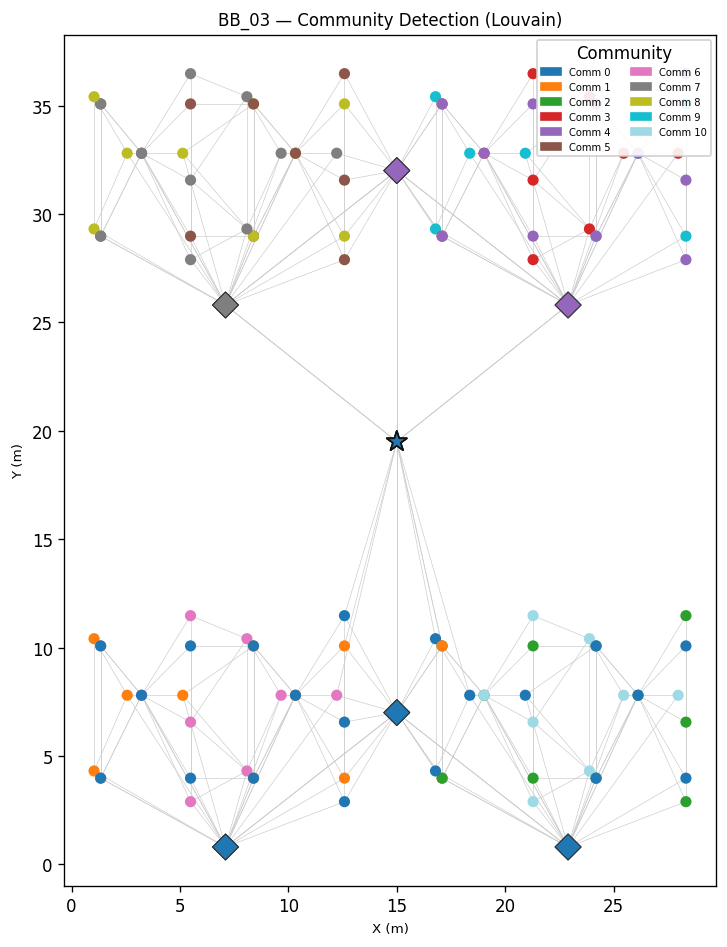

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_03\05_community_detection.png


In [51]:
# Figure 05: community detection

_n_comm    = len(ALL_COMMUNITIES)
_comm_cmap = plt.cm.tab20
_comm_norm = Normalize(vmin=0, vmax=max(_n_comm - 1, 1))

_fig, _ax = plt.subplots(figsize=(12, 8))

for _u, _v in G.edges():
    _x0, _y0 = POS_XY.get(_u, (0, 0))
    _x1, _y1 = POS_XY.get(_v, (0, 0))
    _ax.plot([_x0, _x1], [_y0, _y1], color='#CCCCCC', lw=0.4, zorder=1)

for _role in ('room', 'corridor', 'core'):
    _rn = [n for n in G.nodes() if G.nodes[n].get('node_role') == _role]
    if not _rn:
        continue
    _xs = [POS_XY[n][0] for n in _rn]
    _ys = [POS_XY[n][1] for n in _rn]
    _cs = [_comm_cmap(_comm_norm(NODE_TO_COMM.get(n, 0))) for n in _rn]
    _ax.scatter(_xs, _ys, c=_cs, s=ROLE_SIZE[_role],
                marker=ROLE_MARKER[_role],
                edgecolors=ROLE_EC[_role],
                linewidths=ROLE_EW[_role], zorder=3)

_comm_patches = [
    mpatches.Patch(color=_comm_cmap(_comm_norm(_i)), label=f'Comm {_i}')
    for _i in range(min(_n_comm, 16))
]
_ax.legend(handles=_comm_patches, loc='upper right', fontsize=6,
           framealpha=0.9, ncol=2, title='Community')

_ax.set_title(f'{LAYOUT_ID} — Community Detection ({COMM_METHOD})', fontsize=10)
_ax.set_xlabel('X (m)', fontsize=8)
_ax.set_ylabel('Y (m)', fontsize=8)
_ax.set_aspect('equal')
plt.tight_layout()
_out = os.path.join(VISUALS_DIR, '05_community_detection.png')
_fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_out}')

---
## Verification

In [52]:
EXPECTED_OUTPUTS = [
    os.path.join(RESULTS_DIR, 'metrics_table.csv'),
    os.path.join(RESULTS_DIR, 'graph_summary.csv'),
    os.path.join(RESULTS_DIR, 'component_summary.csv'),
    os.path.join(RESULTS_DIR, 'community_summary.csv'),
    os.path.join(VISUALS_DIR, '01_degree_centrality.png'),
    os.path.join(VISUALS_DIR, '02_betweenness_centrality.png'),
    os.path.join(VISUALS_DIR, '03_closeness_centrality.png'),
    os.path.join(VISUALS_DIR, '04_clustering_coefficient.png'),
    os.path.join(VISUALS_DIR, '05_community_detection.png'),
]

print(f'Output verification for {LAYOUT_ID}:')
_all_ok = True
for _path in EXPECTED_OUTPUTS:
    _ok = os.path.exists(_path)
    _all_ok = _all_ok and _ok
    print(f'  {"OK" if _ok else "MISSING":7s} {os.path.basename(_path)}')

print()
if _all_ok:
    print(f'All outputs present. Proceed to A2_02_TwoBars_Spatial_Interpretation.ipynb.')
else:
    print('Some outputs missing. Scroll up and check for errors in cells above.')

Output verification for BB_03:
  OK      metrics_table.csv
  OK      graph_summary.csv
  OK      component_summary.csv
  OK      community_summary.csv
  OK      01_degree_centrality.png
  OK      02_betweenness_centrality.png
  OK      03_closeness_centrality.png
  OK      04_clustering_coefficient.png
  OK      05_community_detection.png

All outputs present. Proceed to A2_02_TwoBars_Spatial_Interpretation.ipynb.
